En scikit-learn existen varias funciones y clases para buscar automáticamente los mejores parámetros (hyperparameter tuning) de modelos de aprendizaje automático.

Las más importantes son:
GridSearchCV: es la más conocida.
Prueba todas las combinaciones posibles de parámetros.


Ventajas

·                  Encuentra muy buenos parámetros

·                  Fácil de usar

·                  Muy usado en investigación y enseñanza


Desventajas

·                  Puede ser MUY lento

·                  Si hay muchos parámetros explota combinatoriamente




RandomizedSearchCV

En vez de probar todas las combinaciones, prueba combinaciones aleatorias.

Ventajas

·                  Mucho más rápido

·                  Ideal para muchos parámetros

·                  Muy usado en problemas reales

Desventajas

·                  No garantiza probar la mejor combinación exacta

cross_val_score
No busca parámetros automáticamente, pero sirve para evaluar modelos con validación cruzada.

Pipeline + búsqueda de parámetros

Muy importante en proyectos reales.

Permite buscar parámetros de:

·                  preprocessing

·                  escalado

·                  selección de variables

·                  modelo

Básicamente hacemos todo junto.



HalvingGridSearchCV: Muy útil en datasets grandes.

Versión más eficiente de Grid Search.

Empieza probando muchas combinaciones con pocos recursos y va descartando las peores.

Agrupación de datos sin etiquetas (Clustering)

Podemos utilizar sklearn para trabajar con agrupaciones de datos sin etiquetar, es decir que no necesitamos las etiquetas como en el caso de los métodos supervisados, sino solo sus características y esperaríamos que el método encuentre algún patrón para realizar la clasificación. Cada algoritmo de agrupación viene en dos variantes:

●               una clase, que implementa el método de ajuste para aprender los agrupamientos en datos.

●               una función, que, dados los datos, retorna una serie de etiquetas de números enteros correspondientes a los diferentes agrupamientos.



K-means


El algoritmo KMeans agrupa los datos al tratar de separar muestras en n grupos de igual varianza, minimizando un criterio conocido como la inercia o la suma de cuadrados dentro del clúster. Este algoritmo requiere que se especifique la cantidad de grupos. Se adapta bien a un gran número de muestras y se ha utilizado en una amplia gama de áreas de aplicación en muchos campos diferentes. El algoritmo k-means divide un conjunto X de N muestras en K grupos separados C, cada una descrita por la media µ𝑗 de las muestras en el grupo. Las medias son comúnmente llamadas los "centroides", los cuales no son en general puntos de X aún cuando conviven en el mismo espacio. El algoritmo K-means tiene como objetivo elegir los centroides que minimizan la inercia, o el criterio de suma de cuadrados dentro del grupo:



La inercia se puede tomar como una medida de cuán coherentes son los grupos internamente. Tiene varios inconvenientes:

●               La inercia asume que los conglomerados son convexos e isotrópicos, lo que no siempre es así. Responde mal a los grupos alargados, o múltiples con formas irregulares.

●               La inercia no es una métrica normalizada: solo sabemos que los valores más bajos son mejores y que el cero es óptimo. Pero en espacios de muy alta dimensión, las distancias euclidianas tienden a inflarse (esto es un ejemplo de la llamada "maldición de la dimensionalidad"). La ejecución de un algoritmo de reducción de dimensionalidad como el análisis de componentes principales (PCA) antes de la agrupación de k-means puede aliviar este problema y acelerar los cálculos.

K-means se conoce a menudo como el algoritmo de Lloyd. En términos básicos, el algoritmo tiene tres pasos.

1.               El primer paso elige los centroides iniciales, con el método más básico para elegir muestras del conjunto de datos. ¿Cómo sabemos qué valor de centroides es adecuado? Un método común es el Método del codo, te invito a ver el siguiente video para entenderlo mejor


2.              Después de la inicialización, K-means consiste en hacer un bucle entre los otros dos pasos.

a.             El primer paso asigna cada muestra a su centroide más cercano.

b.             El segundo paso crea nuevos centroides tomando el valor medio de todas las muestras asignadas a cada centroide anterior.

La diferencia entre los centroides antiguos y los nuevos se calcula y el algoritmo repite estos dos últimos pasos hasta que este valor es menor que un determinado umbral. En otras palabras, se repite hasta que los centroides no se mueven significativamente.

Dado el tiempo suficiente, K-medias siempre convergerá, sin embargo, esto puede ser a un mínimo local. Esto depende en gran medida de la inicialización de los centroides. Como resultado, el cálculo a menudo se realiza varias veces, con diferentes inicializaciones de los centroides. Un método para ayudar a resolver este problema es el esquema de inicialización k-means ++, que se ha implementado en scikit-learn (use el parámetro init = 'k-means ++'). Esto inicializa los centroides para que estén (generalmente) distantes entre sí, lo que lleva a resultados probablemente mejores.

El algoritmo admite ponderaciones de muestra, que se pueden dar mediante un parámetro sample_weight. Esto permite asignar más peso a algunas muestras al calcular centros de clúster y valores de inercia.

Veamos cómo este método clasifica los puntos de nuestra librería de datos iris, partamos de importar las librerías y el conjunto de datos con sus etiquetas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import datasets
from sklearn import metrics

iris = datasets.load_iris()
datos = iris.data
etiquetas = iris.target

k_means = KMeans(n_init='auto', n_clusters=3, random_state=0)
k_means.fit(datos)

# Predicciones del grupo al que cree que pertenece
predicciones = k_means.predict(datos)

score = metrics.adjusted_rand_score(etiquetas, predicciones)
print(score)



0.7163421126838476


MiniBatchKMeans

El algoritmo K-mean posee una variante llamada MiniBatchKMeans el cual utiliza mini lotes para reducir el tiempo de cálculo, mientras intenta optimizar la misma función objetivo. Los mini lotes son subconjuntos de los datos de entrada, muestreados aleatoriamente en cada iteración de entrenamiento. Estos mini lotes reducen drásticamente la cantidad de cálculos necesarios para converger a una solución local. En contraste con otros algoritmos que reducen el tiempo de convergencia de k-means, los mini-batch-k-means producen resultados que son generalmente solo un poco peores que el algoritmo estándar. MiniBatchKMeans converge más rápido que KMeans, pero la calidad de los resultados se reduce, en la práctica, esta diferencia en la calidad puede ser bastante pequeña, de hecho si en nuestro caso anterior ejecutamos este método obtenemos para tres centroides un porcentaje ligeramente superior del 75,8% contra el 73% que habíamos obtenido.



Affinity Propagation

La propagación por afinidad crea clústeres enviando mensajes entre pares de muestras hasta la convergencia, luego se describe un conjunto de datos utilizando un pequeño número de ejemplares, que se identifican como los más representativos de otras muestras. Los mensajes enviados entre pares representan la idoneidad para que una muestra sea el ejemplar de la otra, que se actualiza en respuesta a los valores de otros pares. Esta actualización ocurre de manera iterativa hasta la convergencia, momento en el que se eligen los ejemplares finales y, por lo tanto, se proporciona la agrupación final.

La propagación de afinidad puede retorna la cantidad de clústeres en función de los datos proporcionados, para este propósito, los dos parámetros importantes son:

●               preference, el cual controla cuántos ejemplares se utilizan

●               damping (factor de amortiguamiento) evita oscilaciones numéricas.

Podemos modificar un poco nuestro código anterior para utilizarlo con este método y comparar los resultados obtenidos:



Numero estimado de clusters: 3
0.8022085453675192


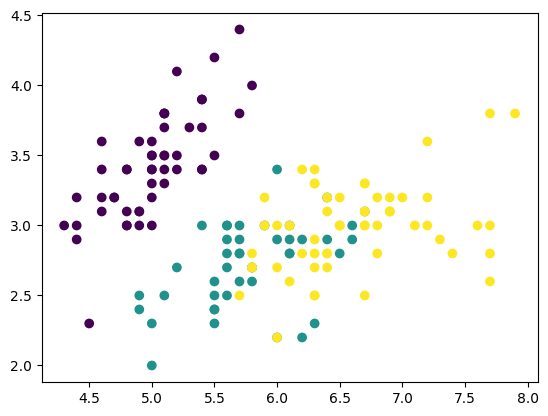

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AffinityPropagation
from sklearn import datasets
from sklearn import metrics

iris = datasets.load_iris()
datos = iris.data
etiquetas = iris.target

afinidad_por_propagacion = AffinityPropagation(preference=-50, damping = 0.5, random_state=None)

af = afinidad_por_propagacion.fit(datos)

cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_

n_clusters_ = len(cluster_centers_indices)

print('Numero estimado de clusters: %d' % n_clusters_)

af.fit(datos)
predicciones = af.predict(datos)
score = metrics.adjusted_rand_score(etiquetas, predicciones)
print(score)
plt.scatter(datos[:, 0], datos[:, 1], c=predicciones)
plt.show()




# Instancia de Autoevaluación: Entrega de tarea

En esta instancia de autoevaluación vamos a poner en juego todos los conocimientos que hemos recorrido juntos en esta clase.  Tendremos en cuenta los tipos de ejercicios que realizamos la teoría que leímos y los ejemplos que vimos en los diferentes recursos.

Trabajaremos con el dataset disponible en campus el cual contiene los siguientes datos sobre clientes:

1.               purchase_freq_month — frecuencia de compras por mes (escala baja a media).

2.              avg_basket_usd — ticket/promedio por compra en USD (escala media a alta).

3.              time_on_site_min — tiempo de permanencia en el sitio (minutos).

4.             discount_sensitivity — sensibilidad a descuentos (0 a 1).

5.             returns_rate — tasa de devoluciones (0 a 0.8 aprox.).

Pista: algunas variables deberían ser escaladas antes de aplicar K-Means.


Qué se quiere descubrir con K-Means

●                    Objetivo: identificar cuántos segmentos latentes de clientes existen a partir de sus comportamientos de compra y uso del sitio, sin etiquetas previas.

●                    Qué patrones buscar:

o        Grupos con frecuencia alta pero ticket bajo y alta sensibilidad a descuentos.

o        Grupos con frecuencia baja pero ticket alto y baja sensibilidad (compras esporádicas pero grandes).

o        Grupos con tiempo en sitio y tasa de devoluciones diferenciados (p. ej., exploran mucho y devuelven más vs. exploran poco y devuelven menos).

●                    Cómo validarlo:

o        Comparar k=2..6 usando método del codo para justificar qué valor de k es razonable.

o        Analizar los centroides por cluster para describir perfiles (p. ej., “Cluster 1: alta frecuencia + ticket medio + sensibilidad media, foco para promociones; Cluster 2: ticket alto + baja sensibilidad, foco en upselling premium”, etc.).

En esta instancia deberás compartir tu jupyter notebook en tu repositorio GIT.



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


dat_csv = pd.read_csv('dataset_segmentacion_clientes.csv', encoding = "ISO-8859-1")
dat_csv.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


Luego de importar los datos voy a tomar el ejemplo y empezar a aplicarlo en mis trabajos, voy a observar el tipo de datos y la descripción, buscando nulos o información que puedan afectar en el analisis

In [4]:
dat_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [5]:
dat_csv.describe()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


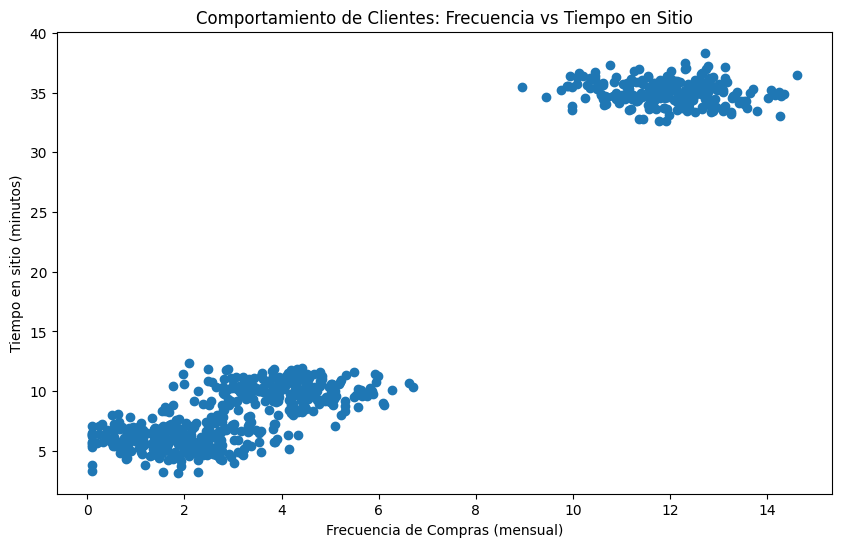

In [6]:
plt.figure(figsize=(10,6))

plt.scatter(
    dat_csv['purchase_freq_month'],
    dat_csv['time_on_site_min']
)

plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.title('Comportamiento de Clientes: Frecuencia vs Tiempo en Sitio')

plt.show()

Voy a crear 3 gráficos para practicar visualizaciones

1 - Frecuencia en compras VS Tiempo en el sitio agruoados por el promedio de compra en USD

Se ve una clara relación entre los datos

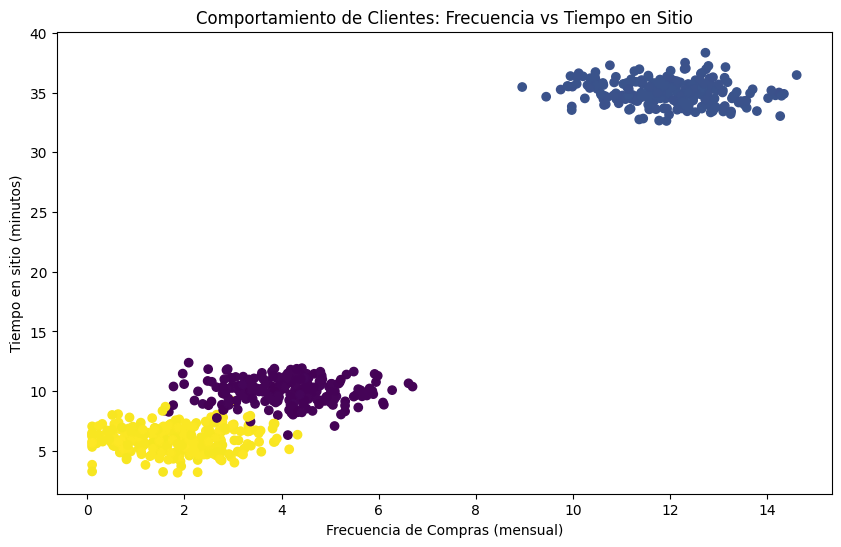

In [7]:
plt.figure(figsize=(10,6))

plt.scatter(
    dat_csv['purchase_freq_month'],
    dat_csv['time_on_site_min'],
    c = dat_csv['avg_basket_usd'],
    cmap = 'viridis'
)

plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.title('Comportamiento de Clientes: Frecuencia vs Tiempo en Sitio')

plt.show()

2 - Frecuencia en compras VS Tiempo en el sitio agruoados por la sensibilidad a descuentos

En este caso, no se puede observar una relación entre los datos con el agrupamiento de sensibilidad a descuentos

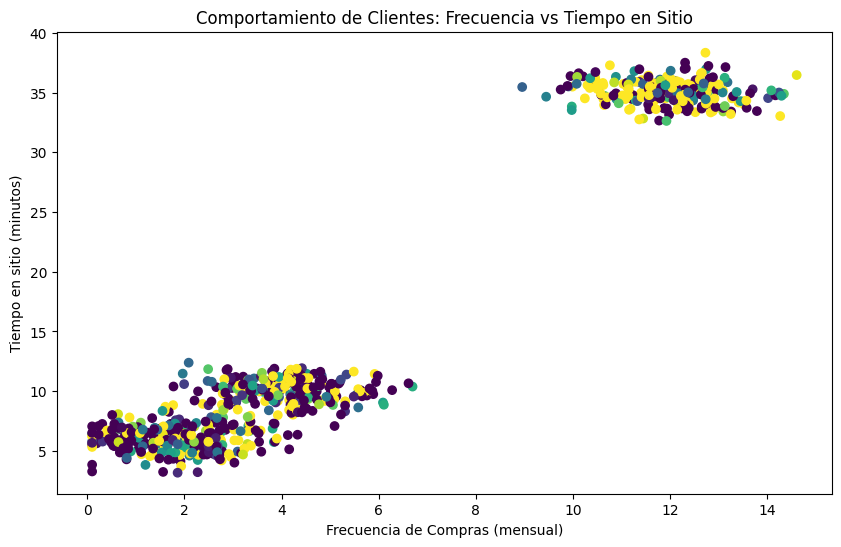

In [8]:
plt.figure(figsize=(10,6))

plt.scatter(
    dat_csv['purchase_freq_month'],
    dat_csv['time_on_site_min'],
    c = dat_csv['discount_sensitivity'],
    cmap = 'viridis'
)

plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.title('Comportamiento de Clientes: Frecuencia vs Tiempo en Sitio')

plt.show()

3 - Frecuencia en compras VS Tiempo en el sitio agruoados por la sensibilidad a descuentos en tamaño (sin correlación) y con agrupamiento en color en cuanto a promedio de ticket de compra.



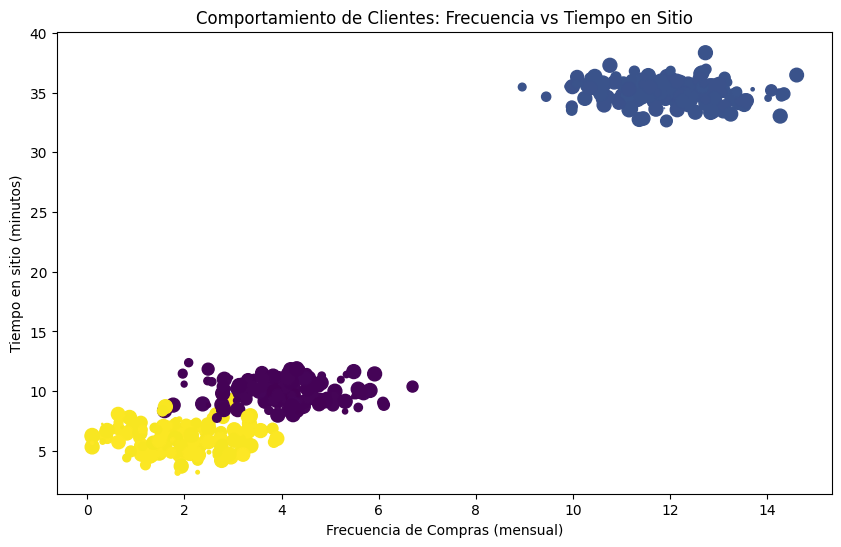

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(
    dat_csv['purchase_freq_month'],
    dat_csv['time_on_site_min'],
    c = dat_csv['avg_basket_usd'],
    s = dat_csv['discount_sensitivity'] * 100,
    cmap = 'viridis'
)

plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.title('Comportamiento de Clientes: Frecuencia vs Tiempo en Sitio')

plt.show()

Podemos observar dos claros agrupamientos de datos, sin necesidad de realizar el método del codo aprendido en Minería de Datos, podemos identificar que la cantidad de segmentos o "K", son 2, pero voy a realizarlo para poder visualizar verificar la hipótesis.


4 - Frecuencia en compras VS Tiempo en el sitio agrupados según la tasa de  devoluciones

Encontramos el mismo caso que Descuentos, a simple vista, no hay una relacion en cuanto el agrupamiento de datos.

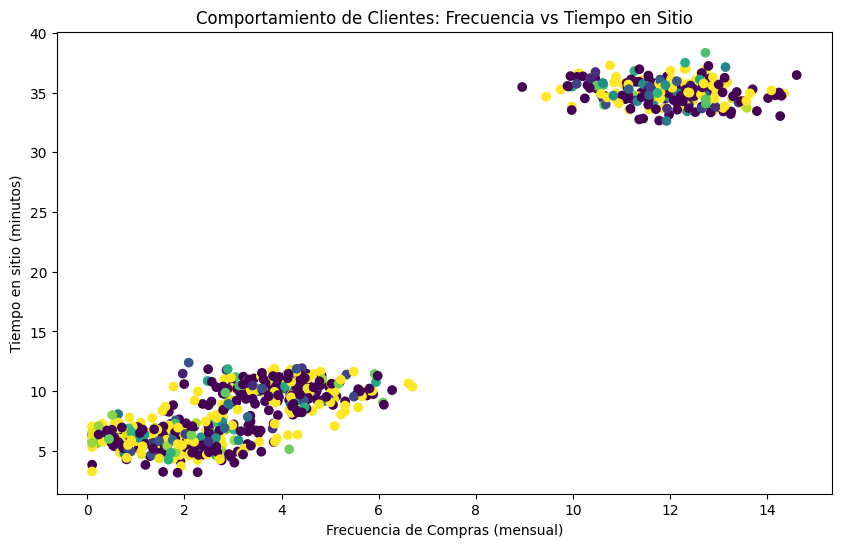

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    dat_csv['purchase_freq_month'],
    dat_csv['time_on_site_min'],
    c = dat_csv['returns_rate'],
    cmap = 'viridis'
)

plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.title('Comportamiento de Clientes: Frecuencia vs Tiempo en Sitio')

plt.show()

## Método del Codo

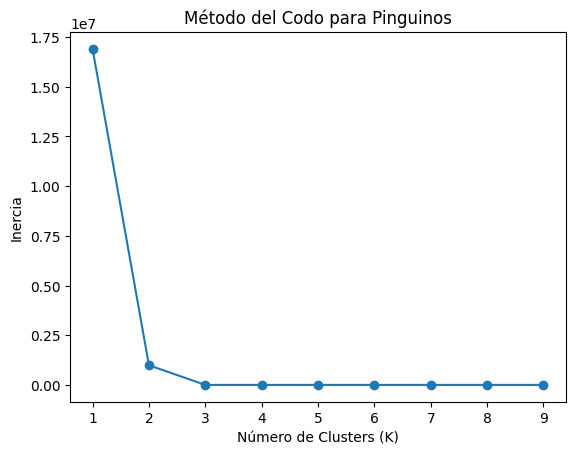

In [11]:
X = dat_csv[['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity', 'returns_rate']]
scaler = StandardScaler()

# Calcular la inercia para diferentes valores de K
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para Pinguinos")
plt.show()

## Método del Codo con StandarScaler (estandarización de datos)

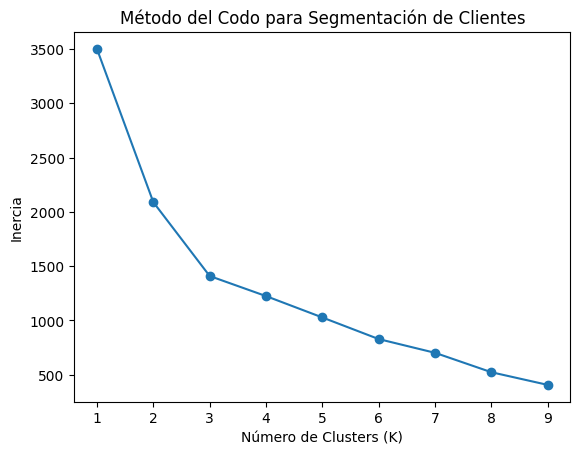

In [12]:
X = dat_csv[['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity', 'returns_rate']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calcular la inercia para diferentes valores de K
inercia = []
valores_k = range(1, 10)
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.plot(valores_k, inercia, marker="o", linestyle="-")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inercia")
plt.title("Método del Codo para Segmentación de Clientes") # Corrected title
plt.show()

## Validación con k=2.6 + centroides


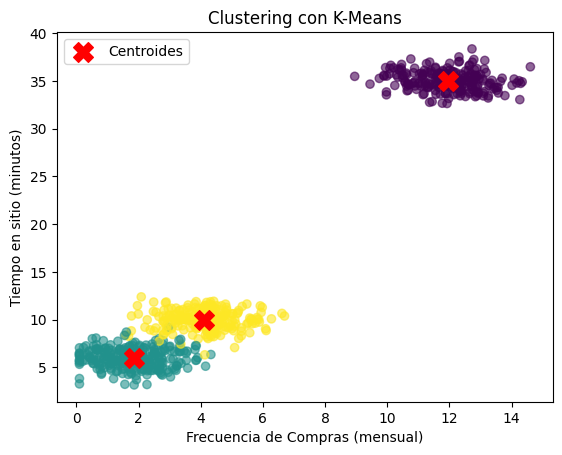

In [13]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = dat_csv[['purchase_freq_month', 'time_on_site_min', 'avg_basket_usd']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
dat_csv["Cluster"] = kmeans.fit_predict(X)

plt.scatter(X['purchase_freq_month'], X['time_on_site_min'], c=dat_csv["Cluster"], cmap="viridis", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")

plt.title("Clustering con K-Means")
plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.legend()
plt.show()

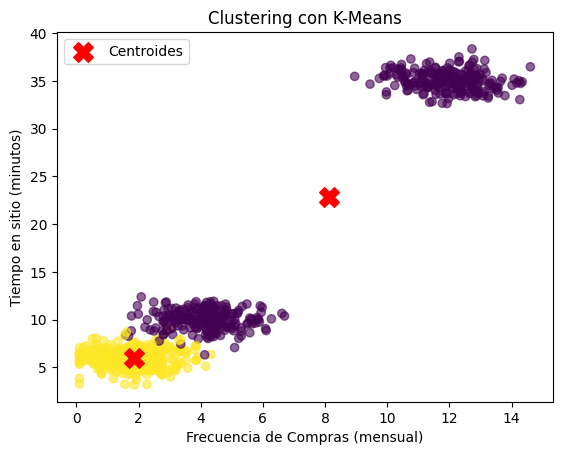

In [14]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = dat_csv[['purchase_freq_month', 'time_on_site_min', 'avg_basket_usd']]
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
dat_csv["Cluster"] = kmeans.fit_predict(X)

plt.scatter(X['purchase_freq_month'], X['time_on_site_min'], c=dat_csv["Cluster"], cmap="viridis", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")

plt.title("Clustering con K-Means")
plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.legend()
plt.show()

La actividad pedía un Clustering de 2.6 pero me toma error, ahora por ultimo voy a hacer un clustering con todas las variables teniendo en cuenta todo lo aprendido a lo largo de la clase


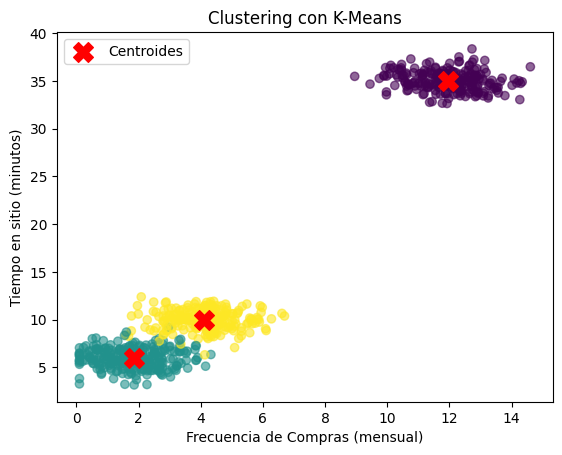

In [15]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

X = dat_csv[['purchase_freq_month', 'time_on_site_min', 'avg_basket_usd', 'returns_rate', 'discount_sensitivity']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
dat_csv["Cluster"] = kmeans.fit_predict(X)

plt.scatter(X['purchase_freq_month'], X['time_on_site_min'], c=dat_csv["Cluster"], cmap="viridis", alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="Centroides")

plt.title("Clustering con K-Means")
plt.xlabel('Frecuencia de Compras (mensual)')
plt.ylabel('Tiempo en sitio (minutos)')
plt.legend()
plt.show()

Se mantienen los resultados, se clasifican en 3 variables, siendo las mismas

Cluster 1 CELESTE: Personas con poca frecuencia de compra, poco tiempo en el sitio y poco dinero gastado

Cluster 2 AMARILLO: Personas con una frecuencia de compra mayor, aún poco tiempo en el sitio pero más que el Cluster 1 y poco dinero promedio gastado siendo este más que el Cluster 1

Cluster 3 VIOLETA:  Personas con una alta frecuencia de compra, mucho tiempo en el sitio, y mucho dinero promedio gastado
